# 🛡️ SentinelNet — AI-Powered Network Intrusion Detection System (NIDS)

**Dataset:** NSL-KDD  
**Goal:** Classify network traffic as Normal / DoS / Probe / R2L / U2R using machine learning

---

## Project Modules
| Week | Module |
|------|--------|
| 1 | Dataset Acquisition & Exploration |
| 2 | Data Cleaning & Preprocessing |
| 3 | Feature Engineering & Selection |
| 4 | Supervised Model Training |
| 5 | Anomaly Detection (Unsupervised) |
| 6 | Model Evaluation & Fine-Tuning |
| 7 | Alert Generation & Logging |
| 8 | Documentation & Summary |

---
## 📦 Install Dependencies

In [ ]:
# Install required packages (run once)
!pip install xgboost imbalanced-learn --quiet

---
## 🔧 Global Imports & Configuration

In [ ]:
import os
import json
import joblib
import warnings
import requests
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import (
    LabelEncoder, StandardScaler, RobustScaler,
    OneHotEncoder, label_binarize
)
from sklearn.model_selection import (
    train_test_split, GridSearchCV,
    StratifiedKFold, cross_val_score
)
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, IsolationForest
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score,
    precision_score, recall_score,
    roc_curve, auc
)
from imblearn.over_sampling import SMOTE

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
    print('XGBoost available.')
except ImportError:
    XGBOOST_AVAILABLE = False
    print('XGBoost not installed — will skip.')

warnings.filterwarnings('ignore')
plt.style.use('ggplot')
sns.set_palette('husl')

# ── Reproducibility ──────────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Directories ──────────────────────────────────────────────────────────────
DATA_DIR    = 'data'
MODELS_DIR  = 'models'
ALERTS_DIR  = 'alerts'
PROC_DIR    = os.path.join(DATA_DIR, 'processed')

for d in [DATA_DIR, MODELS_DIR, ALERTS_DIR, PROC_DIR]:
    os.makedirs(d, exist_ok=True)

print('✅ All libraries imported and directories created.')

XGBoost available.
✅ All libraries imported and directories created.


---
## 📋 NSL-KDD Column Schema & Attack Mapping

In [ ]:
# ── Column names for the NSL-KDD dataset ─────────────────────────────────────
COLUMNS = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins',
    'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root',
    'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds',
    'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate',
    'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
    'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label', 'difficulty_level'
]

# ── Attack → category mapping ─────────────────────────────────────────────────
ATTACK_MAPPING = {
    'normal'          : 'normal',
    # DoS
    'back'            : 'DoS', 'land'       : 'DoS', 'neptune'  : 'DoS',
    'pod'             : 'DoS', 'smurf'      : 'DoS', 'teardrop' : 'DoS',
    'mailbomb'        : 'DoS', 'apache2'    : 'DoS', 'processtable': 'DoS', 'udpstorm': 'DoS',
    # Probe
    'satan'           : 'Probe', 'ipsweep'  : 'Probe', 'nmap'     : 'Probe',
    'portsweep'       : 'Probe', 'mscan'    : 'Probe', 'saint'    : 'Probe',
    # R2L
    'guess_passwd'    : 'R2L', 'ftp_write'  : 'R2L', 'imap'      : 'R2L',
    'phf'             : 'R2L', 'multihop'   : 'R2L', 'warezmaster': 'R2L',
    'warezclient'     : 'R2L', 'spy'        : 'R2L', 'xlock'     : 'R2L',
    'xsnoop'          : 'R2L', 'snmpguess'  : 'R2L', 'snmpgetattack': 'R2L',
    'httptunnel'      : 'R2L', 'sendmail'   : 'R2L', 'named'     : 'R2L',
    # U2R
    'buffer_overflow' : 'U2R', 'loadmodule' : 'U2R', 'perl'      : 'U2R',
    'rootkit'         : 'U2R', 'ps'         : 'U2R', 'xterm'     : 'U2R', 'sqlattack': 'U2R'
}

# ── Severity levels for alert generation ─────────────────────────────────────
SEVERITY_MAP = {
    'normal': 'None',
    'DoS'   : 'Critical',
    'Probe' : 'Medium',
    'R2L'   : 'High',
    'U2R'   : 'Critical',
}
SEVERITY_COLOR = {
    'None'    : '#4CAF50',
    'Medium'  : '#FF9800',
    'High'    : '#F44336',
    'Critical': '#9C27B0',
}

print('✅ Schema and mappings defined.')

✅ Schema and mappings defined.


---
# 📅 Week 1 — Dataset Acquisition & Exploration

In [ ]:
# ── Download NSL-KDD dataset ──────────────────────────────────────────────────
URLS = {
    'KDDTrain+.txt': 'https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain+.txt',
    'KDDTest+.txt' : 'https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTest+.txt'
}

def download_file(url, filename):
    path = os.path.join(DATA_DIR, filename)
    if os.path.exists(path):
        print(f'  ✔ Already exists: {filename}')
        return
    print(f'  ⬇ Downloading {filename}...')
    try:
        r = requests.get(url, stream=True)
        r.raise_for_status()
        with open(path, 'wb') as f:
            for chunk in r.iter_content(chunk_size=8192):
                f.write(chunk)
        print(f'  ✅ Saved → {path}')
    except Exception as e:
        print(f'  ❌ Failed: {e}')

print('Downloading NSL-KDD dataset...')
for fname, url in URLS.items():
    download_file(url, fname)
print('Done.')

  ⬇ Downloading KDDTrain+.txt...
  ✅ Saved → data/KDDTrain+.txt
  ⬇ Downloading KDDTest+.txt...
  ✅ Saved → data/KDDTest+.txt
Done.


In [ ]:
# ── Load raw data ─────────────────────────────────────────────────────────────
TRAIN_PATH = os.path.join(DATA_DIR, 'KDDTrain+.txt')
TEST_PATH  = os.path.join(DATA_DIR, 'KDDTest+.txt')

df_train_raw = pd.read_csv(TRAIN_PATH, header=None, names=COLUMNS)
df_test_raw  = pd.read_csv(TEST_PATH,  header=None, names=COLUMNS)

print(f'Train shape : {df_train_raw.shape}')
print(f'Test  shape : {df_test_raw.shape}')
df_train_raw.head()

Train shape : (125973, 43)
Test  shape : (22544, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty_level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [ ]:
# ── Basic statistics ──────────────────────────────────────────────────────────
print('\n--- Dataset Info ---')
df_train_raw.info()
print('\n--- Descriptive Statistics ---')
df_train_raw.describe()


--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  object 
 2   service                      125973 non-null  object 
 3   flag                         125973 non-null  object 
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,difficulty_level
count,125973.00000,1.259730e+05,1.259730e+05,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,...,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000
mean,287.14465,4.556674e+04,1.977911e+04,0.000198,0.022687,0.000111,0.204409,0.001222,0.395736,0.279250,...,115.653005,0.521242,0.082951,0.148379,0.032542,0.284452,0.278485,0.118832,0.120240,19.504060
std,2604.51531,5.870331e+06,4.021269e+06,0.014086,0.253530,0.014366,2.149968,0.045239,0.489010,23.942042,...,110.702741,0.448949,0.188922,0.308997,0.112564,0.444784,0.445669,0.306557,0.319459,2.291503
min,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000
50%,0.00000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,63.000000,0.510000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000
75%,0.00000,2.760000e+02,5.160000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000,21.000000
max,42908.00000,1.379964e+09,1.309937e+09,1.000000,3.000000,3.000000,77.000000,5.000000,1.000000,7479.000000,...,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,21.000000


In [ ]:
# ── Attack type distribution ──────────────────────────────────────────────────
print('Unique attack labels in training set:', df_train_raw['label'].nunique())
print(df_train_raw['label'].value_counts())

Unique attack labels in training set: 23
label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64


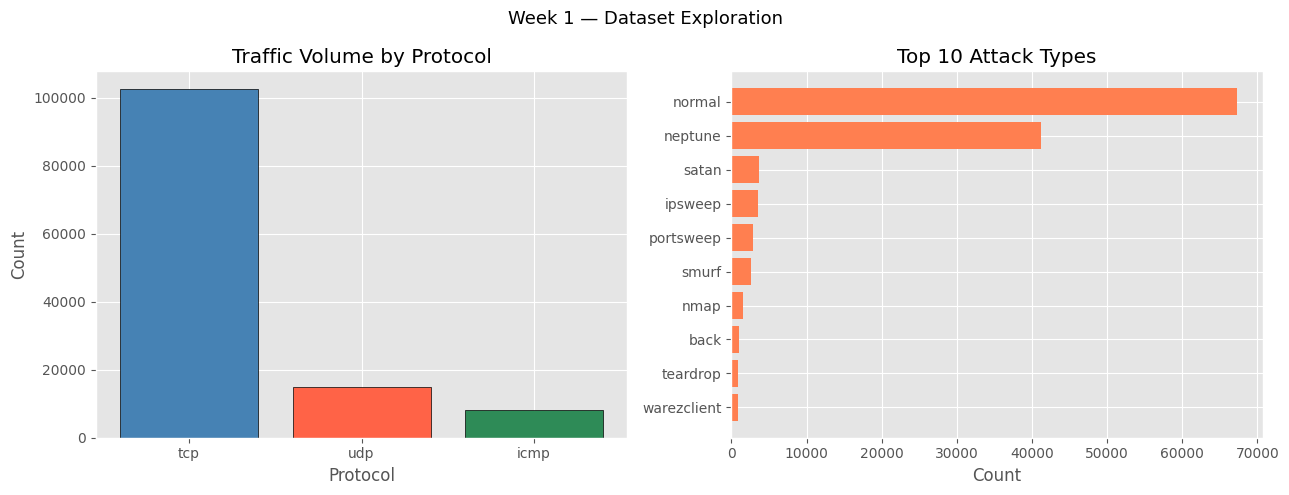


Protocol vs Attack Category:
attack_class     DoS  Probe  R2L  U2R  normal
protocol_type                                
icmp            2847   4135    0    0    1309
tcp            42188   5857  995   49   53600
udp              892   1664    0    3   12434


In [ ]:
# ── Protocol distribution ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Protocol counts
proto_counts = df_train_raw['protocol_type'].value_counts()
axes[0].bar(proto_counts.index, proto_counts.values, color=['steelblue','tomato','seagreen'], edgecolor='black')
axes[0].set_title('Traffic Volume by Protocol')
axes[0].set_xlabel('Protocol')
axes[0].set_ylabel('Count')

# Top 10 attack labels
top_attacks = df_train_raw['label'].value_counts().head(10)
axes[1].barh(top_attacks.index[::-1], top_attacks.values[::-1], color='coral')
axes[1].set_title('Top 10 Attack Types')
axes[1].set_xlabel('Count')

plt.suptitle('Week 1 — Dataset Exploration', fontsize=13)
plt.tight_layout()
plt.show()

print('\nProtocol vs Attack Category:')
df_train_raw['attack_class'] = df_train_raw['label'].map(lambda x: ATTACK_MAPPING.get(x, 'other'))
print(pd.crosstab(df_train_raw['protocol_type'], df_train_raw['attack_class']))

---
# 📅 Week 2 — Data Cleaning & Preprocessing

In [ ]:
# ── Data quality check ────────────────────────────────────────────────────────
print('Missing values  (train):', df_train_raw.isnull().sum().sum())
print('Duplicate rows  (train):', df_train_raw.duplicated().sum())
print('Missing values  (test) :', df_test_raw.isnull().sum().sum())
print('Duplicate rows  (test) :', df_test_raw.duplicated().sum())

Missing values  (train): 0
Duplicate rows  (train): 0
Missing values  (test) : 0
Duplicate rows  (test) : 0


In [ ]:
def preprocess(df, is_train=True, ohe=None, freq_map=None, scaler=None):
    """
    Full preprocessing pipeline:
      1. Map labels → attack_class
      2. One-hot encode protocol_type & flag
      3. Frequency encode service
      4. Log-transform skewed columns
      5. Engineer new features
      6. Drop raw categorical columns
      7. RobustScaler on numeric features
    Returns (df_out, ohe, freq_map, scaler)
    """
    df = df.copy()

    # 1. Attack class mapping
    df['attack_class'] = df['label'].map(lambda x: ATTACK_MAPPING.get(x, 'other'))

    # 2. One-hot encode protocol_type & flag
    cats = ['protocol_type', 'flag']
    if is_train:
        ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
        ohe.fit(df[cats])
    enc_df = pd.DataFrame(
        ohe.transform(df[cats]),
        columns=ohe.get_feature_names_out(cats),
        index=df.index
    )
    df = pd.concat([df, enc_df], axis=1)

    # 3. Frequency encode service
    if is_train:
        freq_map = df['service'].value_counts(normalize=True).to_dict()
    df['service_freq'] = df['service'].map(freq_map).fillna(0)

    # 4. Log-transform skewed columns
    for col in ['src_bytes', 'dst_bytes', 'duration']:
        df[f'log_{col}'] = np.log1p(df[col])

    # 5. Feature engineering
    df['total_bytes']     = df['src_bytes'] + df['dst_bytes']
    df['src_bytes_ratio'] = df['src_bytes'] / (df['total_bytes'] + 1e-5)
    df['is_error_flag']   = df['flag'].isin(['S0','S1','S2','S3','REJ']).astype(int)

    # 6. Drop raw categoricals, label, difficulty
    drop_cols = ['protocol_type', 'flag', 'service', 'label', 'difficulty_level']
    df.drop(columns=drop_cols, inplace=True, errors='ignore')

    # 7. Scale numeric features (everything except attack_class)
    feature_cols = [c for c in df.columns if c != 'attack_class']
    if is_train:
        scaler = RobustScaler()
        scaler.fit(df[feature_cols])
    df[feature_cols] = scaler.transform(df[feature_cols])

    return df, ohe, freq_map, scaler


print('Preprocessing training data...')
df_train_proc, ohe, freq_map, scaler = preprocess(df_train_raw, is_train=True)

print('Preprocessing test data...')
df_test_proc, _, _, _ = preprocess(df_test_raw, is_train=False,
                                    ohe=ohe, freq_map=freq_map, scaler=scaler)

print(f'\nTrain processed shape : {df_train_proc.shape}')
print(f'Test  processed shape : {df_test_proc.shape}')
print('\nClass distribution (train):')
print(df_train_proc['attack_class'].value_counts())

Preprocessing training data...
Preprocessing test data...

Train processed shape : (125973, 60)
Test  processed shape : (22544, 60)

Class distribution (train):
attack_class
normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64


In [ ]:
# ── Remove highly correlated features ────────────────────────────────────────
feature_cols = [c for c in df_train_proc.columns if c != 'attack_class']
corr_matrix  = df_train_proc[feature_cols].corr().abs()
upper        = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop_corr = [c for c in upper.columns if any(upper[c] > 0.95)]

print(f'Dropping {len(to_drop_corr)} highly correlated features: {to_drop_corr}')
df_train_proc.drop(columns=to_drop_corr, inplace=True, errors='ignore')
df_test_proc.drop(columns=to_drop_corr,  inplace=True, errors='ignore')

feature_cols = [c for c in df_train_proc.columns if c != 'attack_class']
print(f'Features remaining: {len(feature_cols)}')

Dropping 7 highly correlated features: ['num_root', 'srv_serror_rate', 'srv_rerror_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_srv_rerror_rate', 'flag_S0']
Features remaining: 52


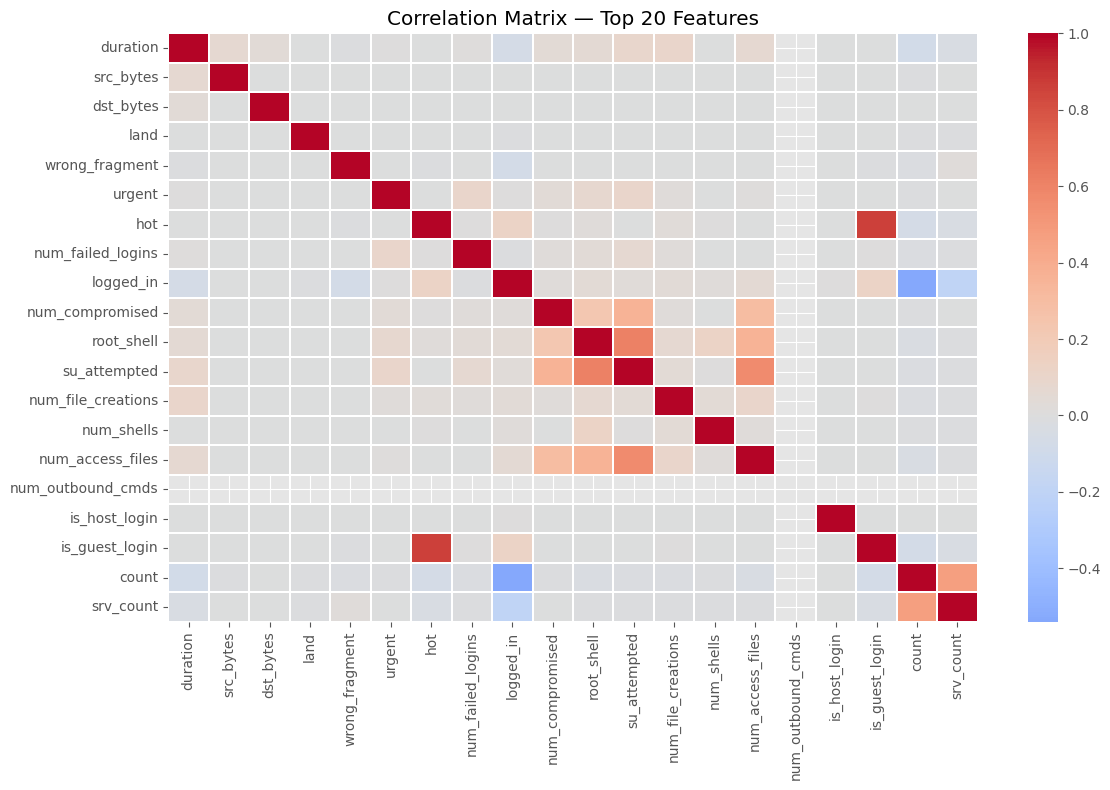

In [ ]:
# ── Correlation heatmap (top 20 features) ────────────────────────────────────
top20 = feature_cols[:20]
plt.figure(figsize=(12, 8))
sns.heatmap(df_train_proc[top20].corr(), cmap='coolwarm', center=0, linewidths=0.3)
plt.title('Correlation Matrix — Top 20 Features')
plt.tight_layout()
plt.show()

---
# 📅 Week 3 — Feature Engineering & Selection

In [ ]:
# ── Oversample minority classes with SMOTE ────────────────────────────────────
X_raw_full = df_train_proc[feature_cols].copy()
y_raw_full = df_train_proc['attack_class'].copy()

print('Class distribution BEFORE SMOTE:')
print(y_raw_full.value_counts())

smote = SMOTE(sampling_strategy='auto', k_neighbors=5, random_state=RANDOM_STATE)
X_resampled, y_resampled = smote.fit_resample(X_raw_full, y_raw_full)
y_resampled = pd.Series(y_resampled, name='attack_class')

print('\nClass distribution AFTER SMOTE:')
print(y_resampled.value_counts())

Class distribution BEFORE SMOTE:
attack_class
normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64

Class distribution AFTER SMOTE:
attack_class
normal    67343
DoS       67343
R2L       67343
Probe     67343
U2R       67343
Name: count, dtype: int64


In [ ]:
# ── Encode target for sklearn models ─────────────────────────────────────────
le = LabelEncoder()
y_encoded = le.fit_transform(y_resampled)
print('Encoded classes:', list(le.classes_))

Encoded classes: ['DoS', 'Probe', 'R2L', 'U2R', 'normal']


In [ ]:
# ── Feature importance via Random Forest ─────────────────────────────────────
print('Training lightweight RF for feature importance...')
rf_imp = RandomForestClassifier(
    n_estimators=100, max_depth=10,
    random_state=RANDOM_STATE, n_jobs=-1
)
rf_imp.fit(X_resampled, y_encoded)

importance = pd.Series(
    rf_imp.feature_importances_,
    index=X_resampled.columns
).sort_values(ascending=False)

print('\nTop 25 Features by Importance:')
print(importance.head(25).to_string())

Training lightweight RF for feature importance...

Top 25 Features by Importance:
service_freq                   0.078412
src_bytes                      0.071528
total_bytes                    0.061355
root_shell                     0.055481
log_src_bytes                  0.055055
dst_host_srv_count             0.052491
src_bytes_ratio                0.045635
dst_bytes                      0.044627
dst_host_same_src_port_rate    0.044369
count                          0.040598
logged_in                      0.037820
log_dst_bytes                  0.037085
serror_rate                    0.037052
dst_host_diff_srv_rate         0.036610
srv_count                      0.030539
diff_srv_rate                  0.028383
num_file_creations             0.026379
same_srv_rate                  0.021586
dst_host_same_srv_rate         0.020908
is_error_flag                  0.019345
hot                            0.018928
dst_host_count                 0.017190
duration                       0.01325

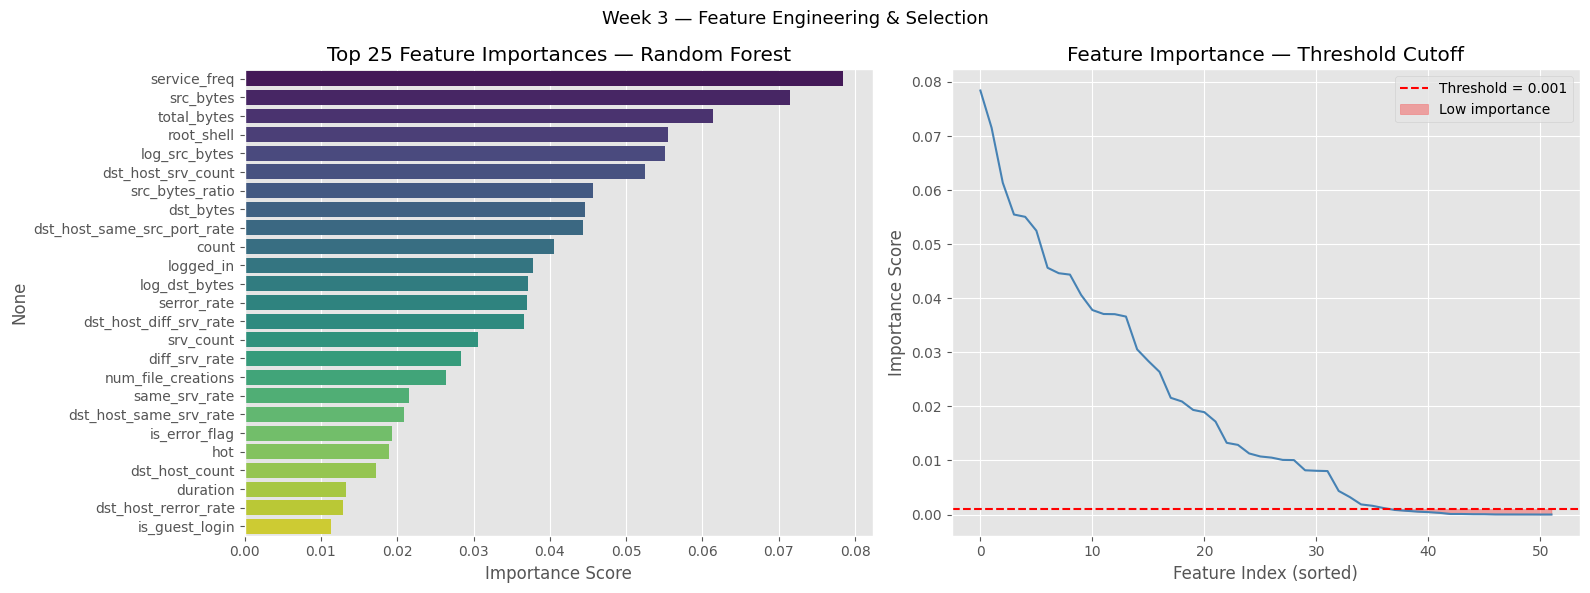

Features kept  (>= 0.001): 37
Features dropped (< 0.001): 15
Dropped: ['flag_REJ', 'flag_RSTR', 'num_access_files', 'num_shells', 'flag_SH', 'urgent', 'su_attempted', 'flag_S3', 'flag_S1', 'land', 'flag_S2', 'flag_RSTOS0', 'flag_OTH', 'is_host_login', 'num_outbound_cmds']


In [ ]:
# ── Feature importance bar chart ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart — top 25
sns.barplot(
    x=importance.head(25).values,
    y=importance.head(25).index,
    palette='viridis', ax=axes[0]
)
axes[0].set_title('Top 25 Feature Importances — Random Forest')
axes[0].set_xlabel('Importance Score')

# Threshold cutoff plot
threshold = 0.001
axes[1].plot(range(len(importance)), importance.values, color='steelblue')
axes[1].axhline(y=threshold, color='red', linestyle='--', label=f'Threshold = {threshold}')
axes[1].fill_between(
    range(len(importance)), importance.values, threshold,
    where=importance.values < threshold, color='red', alpha=0.3, label='Low importance'
)
axes[1].set_title('Feature Importance — Threshold Cutoff')
axes[1].set_xlabel('Feature Index (sorted)')
axes[1].set_ylabel('Importance Score')
axes[1].legend()

plt.suptitle('Week 3 — Feature Engineering & Selection', fontsize=13)
plt.tight_layout()
plt.show()

# Select features above threshold
selected_features = importance[importance >= threshold].index.tolist()
low_importance    = importance[importance < threshold].index.tolist()
print(f'Features kept  (>= {threshold}): {len(selected_features)}')
print(f'Features dropped (< {threshold}): {len(low_importance)}')
if low_importance:
    print('Dropped:', low_importance)

In [ ]:
# ── Apply feature selection ───────────────────────────────────────────────────
X_selected = X_resampled[selected_features]
print(f'Final feature matrix shape: {X_selected.shape}')

Final feature matrix shape: (336715, 37)


Running t-SNE on 3000 samples...


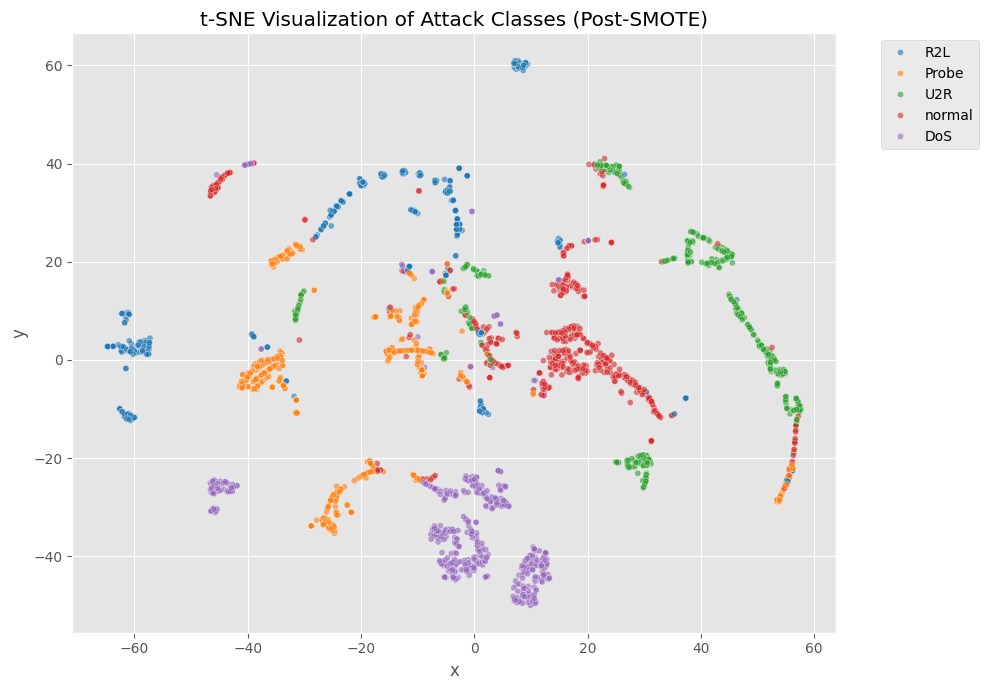

In [ ]:
# ── t-SNE visualization ───────────────────────────────────────────────────────
SAMPLE_SIZE  = 3000
sample_rows  = np.random.choice(len(X_selected), SAMPLE_SIZE, replace=False)
X_tsne_samp  = X_selected.iloc[sample_rows].values
y_tsne_samp  = y_resampled.iloc[sample_rows].values

print(f'Running t-SNE on {SAMPLE_SIZE} samples...')
tsne   = TSNE(n_components=2, perplexity=40, n_iter=1000,
              learning_rate='auto', init='pca', random_state=RANDOM_STATE)
t_res  = tsne.fit_transform(X_tsne_samp)

tsne_df = pd.DataFrame({'x': t_res[:, 0], 'y': t_res[:, 1], 'class': y_tsne_samp})

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=tsne_df, x='x', y='y', hue='class',
    palette='tab10', alpha=0.6, s=20
)
plt.title('t-SNE Visualization of Attack Classes (Post-SMOTE)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
# ── Save processed datasets ───────────────────────────────────────────────────
df_final_train = pd.concat([X_selected, y_resampled], axis=1)

# Test set — use same selected features
X_test_features  = [f for f in selected_features if f in df_test_proc.columns]
df_final_test    = df_test_proc[X_test_features + ['attack_class']].copy()

TRAIN_PROC_PATH = os.path.join(PROC_DIR, 'train_processed_advanced.csv')
TEST_PROC_PATH  = os.path.join(PROC_DIR, 'test_processed_advanced.csv')

df_final_train.to_csv(TRAIN_PROC_PATH, index=False)
df_final_test.to_csv(TEST_PROC_PATH,   index=False)

print(f'Saved train processed → {TRAIN_PROC_PATH}  shape={df_final_train.shape}')
print(f'Saved test  processed → {TEST_PROC_PATH}   shape={df_final_test.shape}')

Saved train processed → data/processed/train_processed_advanced.csv  shape=(336715, 38)
Saved test  processed → data/processed/test_processed_advanced.csv   shape=(22544, 38)


---
# 📅 Week 4 — Supervised Model Training

In [ ]:
# ── Prepare signal arrays ─────────────────────────────────────────────────────
df_train = pd.read_csv(TRAIN_PROC_PATH)
df_test  = pd.read_csv(TEST_PROC_PATH)

X_signal      = df_train.drop(columns=['attack_class']).values
X_test_signal = df_test.drop(columns=['attack_class']).values

le_w4    = LabelEncoder()

# Get all unique classes from both train and test sets to fit the LabelEncoder
all_classes = pd.concat([df_train['attack_class'], df_test['attack_class']]).unique()
le_w4.fit(all_classes)

y_master = le_w4.transform(df_train['attack_class'])
y_test_l = le_w4.transform(df_test['attack_class'])

X_train, X_val, y_train, y_val = train_test_split(
    X_signal, y_master,
    test_size=0.2, random_state=RANDOM_STATE, stratify=y_master
)

print(f'X_train : {X_train.shape} | X_val : {X_val.shape}')
print(f'Classes : {le_w4.classes_}')

X_train : (269372, 37) | X_val : (67343, 37)
Classes : ['DoS' 'Probe' 'R2L' 'U2R' 'normal' 'other']


In [ ]:
# ── Hyperparameter tuning for Random Forest ───────────────────────────────────
print('Starting GridSearchCV for Random Forest...')

param_grid = {
    'n_estimators'    : [50, 100],
    'max_depth'       : [10, 20],
    'min_samples_leaf': [1, 2]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, class_weight='balanced'),
    param_grid, cv=3, scoring='f1_macro', verbose=1
)
grid.fit(X_train, y_train)

sentinel_brain = grid.best_estimator_

print(f'\nBest Hyperparameters : {grid.best_params_}')
print(f'Best CV F1 Score     : {grid.best_score_:.4f}')

Starting GridSearchCV for Random Forest...
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Best Hyperparameters : {'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 100}
Best CV F1 Score     : 0.9996


In [ ]:
# ── Train and compare all models ──────────────────────────────────────────────
models = {
    'Random Forest'     : sentinel_brain,
    'Decision Tree'     : DecisionTreeClassifier(max_depth=15, random_state=RANDOM_STATE),
    'Gradient Boosting' : GradientBoostingClassifier(
                            n_estimators=50, max_depth=3,
                            subsample=0.3, random_state=RANDOM_STATE),
}
if XGBOOST_AVAILABLE:
    models['XGBoost'] = XGBClassifier(
        n_estimators=100, max_depth=6, learning_rate=0.1,
        eval_metric='mlogloss', random_state=RANDOM_STATE
    )

results = {}
for name, model in models.items():
    print(f'\nTraining: {name}...')
    model.fit(X_train, y_train)
    y_pred    = model.predict(X_val)
    acc       = accuracy_score(y_val, y_pred)
    f1        = f1_score(y_val, y_pred, average='macro')
    prec      = precision_score(y_val, y_pred, average='macro', zero_division=0)
    rec       = recall_score(y_val, y_pred, average='macro', zero_division=0)
    results[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1 Macro': f1}
    print(f'  Accuracy : {acc:.4f} | F1 Macro : {f1:.4f}')

results_df = pd.DataFrame(results).T.reset_index().rename(columns={'index': 'Model'})
print('\n--- Final Rankings ---')
print(results_df.sort_values('F1 Macro', ascending=False).to_string(index=False))


Training: Random Forest...
  Accuracy : 0.9997 | F1 Macro : 0.9997

Training: Decision Tree...
  Accuracy : 0.9982 | F1 Macro : 0.9982

Training: Gradient Boosting...
  Accuracy : 0.9912 | F1 Macro : 0.9912

Training: XGBoost...
  Accuracy : 0.9996 | F1 Macro : 0.9996

--- Final Rankings ---
            Model  Accuracy  Precision   Recall  F1 Macro
    Random Forest  0.999718   0.999718 0.999718  0.999718
          XGBoost  0.999555   0.999554 0.999555  0.999554
    Decision Tree  0.998218   0.998221 0.998218  0.998217
Gradient Boosting  0.991165   0.991168 0.991164  0.991162


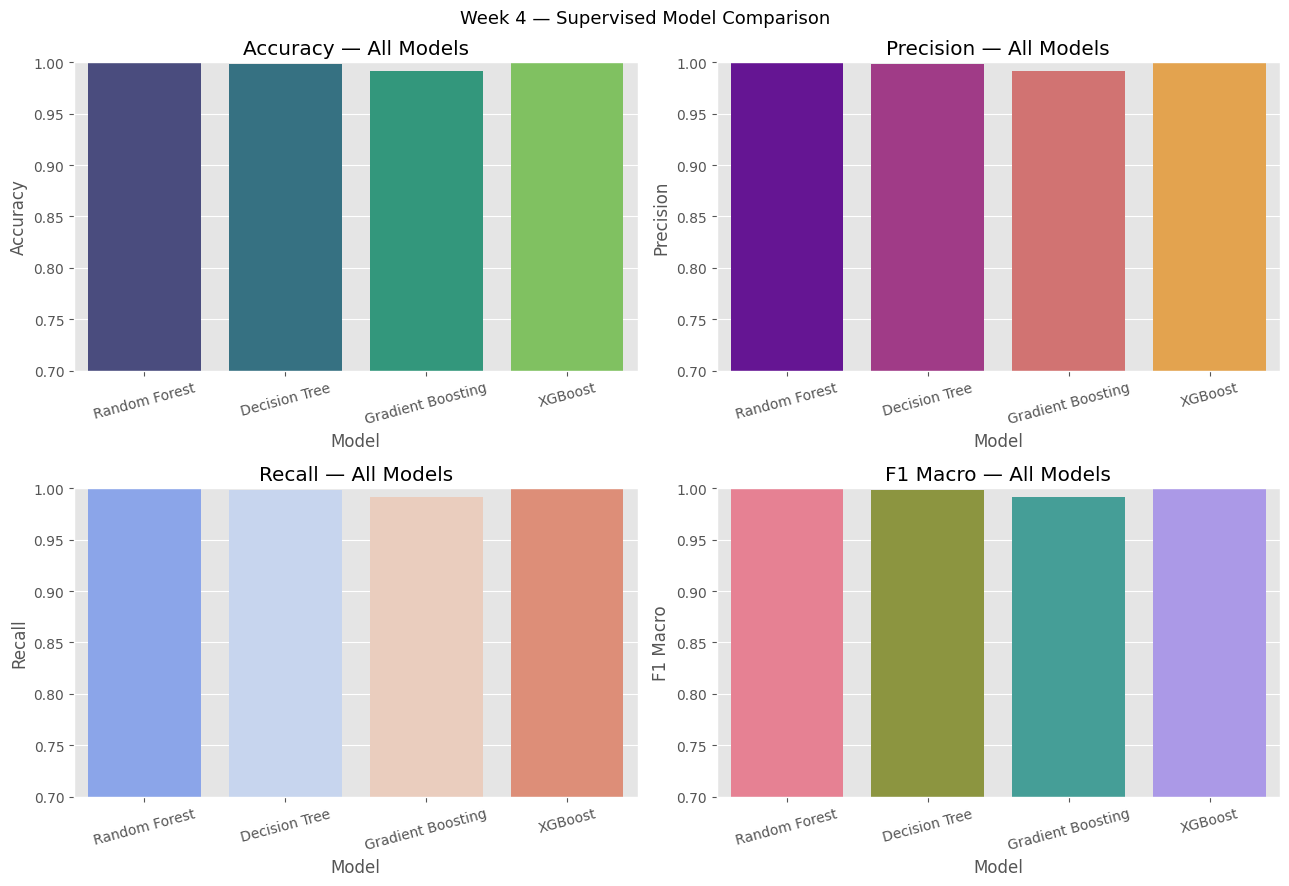

In [ ]:
# ── Model comparison chart ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
metrics  = ['Accuracy', 'Precision', 'Recall', 'F1 Macro']
palettes = ['viridis', 'plasma', 'coolwarm', 'husl']

for ax, metric, palette in zip(axes.flatten(), metrics, palettes):
    sns.barplot(data=results_df, x='Model', y=metric, palette=palette, ax=ax)
    ax.set_title(f'{metric} — All Models')
    ax.set_ylim(0.7, 1.0)
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Week 4 — Supervised Model Comparison', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# ── Classification report for best model ─────────────────────────────────────
y_pred_best    = sentinel_brain.predict(X_val)
unique_classes = sorted(np.unique(np.concatenate([y_val, y_pred_best])))
class_names    = [le_w4.classes_[i] for i in unique_classes]

print('Classification Report — Random Forest (Best)')
print(classification_report(y_val, y_pred_best, target_names=class_names))

Classification Report — Random Forest (Best)
              precision    recall  f1-score   support

         DoS       1.00      1.00      1.00     13469
       Probe       1.00      1.00      1.00     13468
         R2L       1.00      1.00      1.00     13469
         U2R       1.00      1.00      1.00     13469
      normal       1.00      1.00      1.00     13468

    accuracy                           1.00     67343
   macro avg       1.00      1.00      1.00     67343
weighted avg       1.00      1.00      1.00     67343



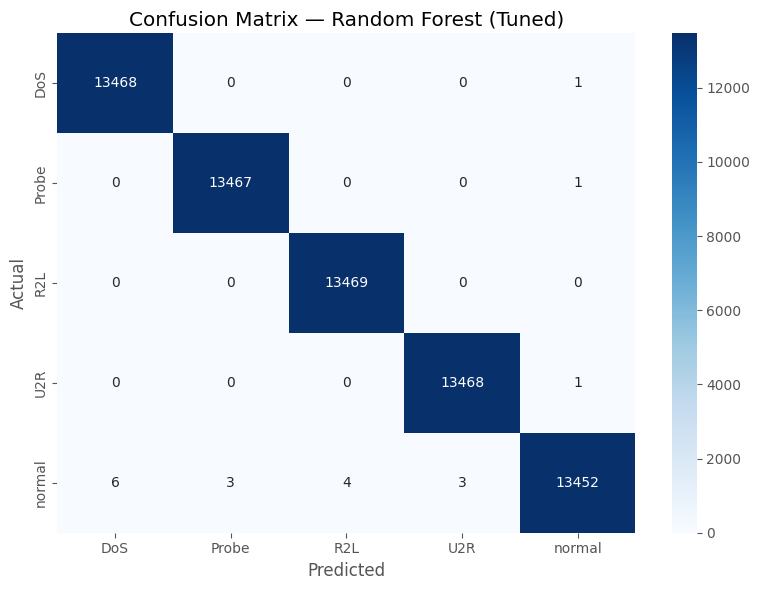

In [ ]:
# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_val, y_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix — Random Forest (Tuned)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [ ]:
# ── Save model & encoder ─────────────────────────────────────────────────────
joblib.dump(sentinel_brain, os.path.join(MODELS_DIR, 'sentinel_brain.joblib'))
joblib.dump(le_w4,          os.path.join(MODELS_DIR, 'label_encoder.joblib'))
print('✅ Model saved → models/sentinel_brain.joblib')
print('✅ Encoder saved → models/label_encoder.joblib')

✅ Model saved → models/sentinel_brain.joblib
✅ Encoder saved → models/label_encoder.joblib


---
# 📅 Week 5 — Anomaly Detection (Unsupervised Learning)

In [ ]:
# ── Isolation Forest ─────────────────────────────────────────────────────────
print('Running Isolation Forest on full training set...')
iso       = IsolationForest(contamination=0.03, random_state=RANDOM_STATE, n_jobs=-1)
iso_preds = iso.fit_predict(X_signal)

iso_plot_df             = df_train.copy()
iso_plot_df['iso_score']  = iso.decision_function(X_signal)
iso_plot_df['is_anomaly'] = (iso_preds == -1).astype(int)

iso_anomaly_count = iso_plot_df['is_anomaly'].sum()
print(f'Isolation Forest — Anomalies detected: {iso_anomaly_count}')

Running Isolation Forest on full training set...
Isolation Forest — Anomalies detected: 10092


In [ ]:
# ── LOF & One-Class SVM on sample ─────────────────────────────────────────────
SAMPLE_5K = 5000
X_sample5 = X_signal[:SAMPLE_5K]

print('Running Local Outlier Factor...')
lof             = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
lof_labels      = lof.fit_predict(X_sample5)
lof_count       = (lof_labels == -1).sum()
print(f'LOF — Anomalies: {lof_count}')

print('Running One-Class SVM...')
oc_svm          = OneClassSVM(kernel='rbf', gamma=0.1, nu=0.05)
oc_svm.fit(X_sample5)
ocsvm_preds     = oc_svm.predict(X_sample5)
ocsvm_count     = (ocsvm_preds == -1).sum()
print(f'One-Class SVM — Anomalies: {ocsvm_count}')

comparison = pd.DataFrame({
    'Method'            : ['Isolation Forest', 'Local Outlier Factor', 'One-Class SVM'],
    'Anomalies Detected': [iso_anomaly_count, lof_count, ocsvm_count],
    'Sample Size'       : [len(X_signal), SAMPLE_5K, SAMPLE_5K],
    'Speed'             : ['Fast', 'Slow', 'Medium'],
    'Best For'          : ['Global outliers', 'Local/cluster outliers', 'Known normal data']
})
print('\nAnomaly Detection Comparison')
print(comparison.to_string(index=False))

Running Local Outlier Factor...
LOF — Anomalies: 250
Running One-Class SVM...
One-Class SVM — Anomalies: 439

Anomaly Detection Comparison
              Method  Anomalies Detected  Sample Size  Speed               Best For
    Isolation Forest               10092       336715   Fast        Global outliers
Local Outlier Factor                 250         5000   Slow Local/cluster outliers
       One-Class SVM                 439         5000 Medium      Known normal data


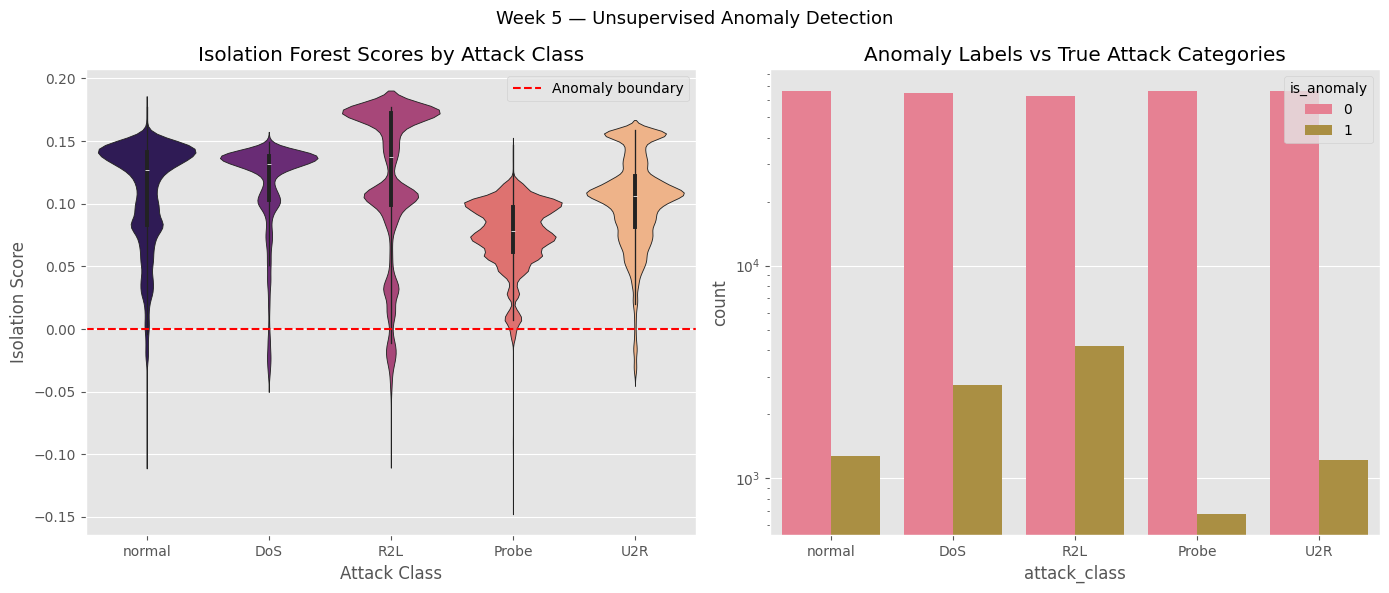

In [ ]:
# ── Anomaly visualization ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.violinplot(
    x='attack_class', y='iso_score',
    data=iso_plot_df, palette='magma', ax=axes[0]
)
axes[0].axhline(0, color='red', linestyle='--', label='Anomaly boundary')
axes[0].set_title('Isolation Forest Scores by Attack Class')
axes[0].set_xlabel('Attack Class')
axes[0].set_ylabel('Isolation Score')
axes[0].legend()

sns.countplot(
    x='attack_class', hue='is_anomaly',
    data=iso_plot_df, ax=axes[1]
)
axes[1].set_title('Anomaly Labels vs True Attack Categories')
axes[1].set_yscale('log')

plt.suptitle('Week 5 — Unsupervised Anomaly Detection', fontsize=13)
plt.tight_layout()
plt.show()

---
# 📅 Week 6 — Model Evaluation & Fine-Tuning

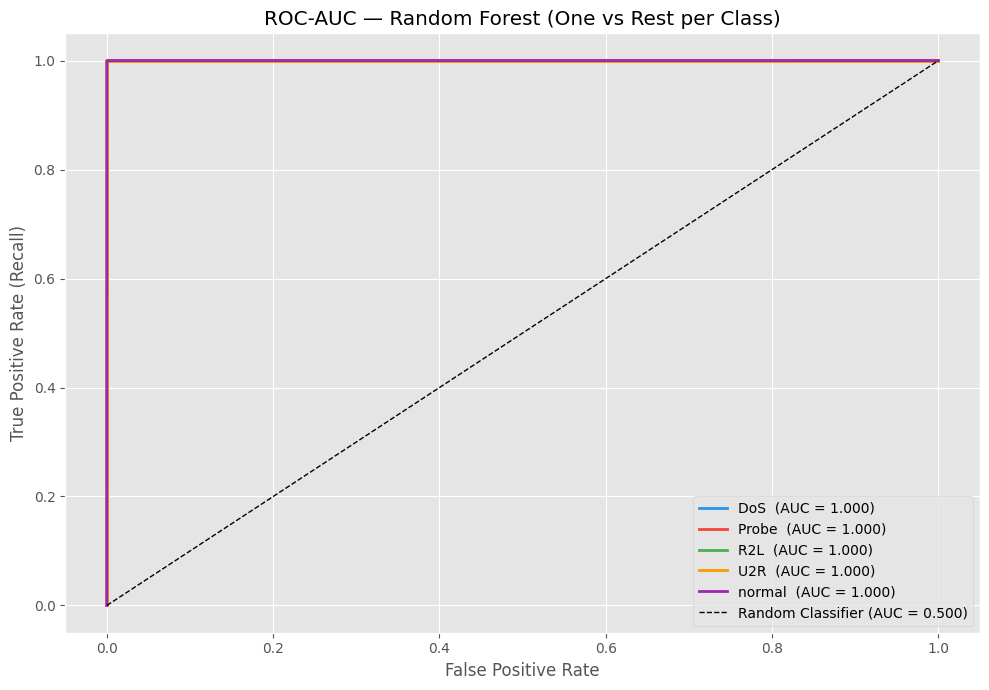

In [ ]:
# ── ROC-AUC curves ────────────────────────────────────────────────────────────
n_classes  = len(le_w4.classes_)
y_val_bin  = label_binarize(y_val, classes=list(range(n_classes)))
y_prob     = sentinel_brain.predict_proba(X_val)

colors_roc = ['#2196F3', '#F44336', '#4CAF50', '#FF9800', '#9C27B0']

plt.figure(figsize=(10, 7))
for i, (cls_name, color) in enumerate(zip(le_w4.classes_, colors_roc[:n_classes])):
    fpr, tpr, _ = roc_curve(y_val_bin[:, i], y_prob[:, i])
    roc_auc     = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{cls_name}  (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier (AUC = 0.500)')
plt.title('ROC-AUC — Random Forest (One vs Rest per Class)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

Cross Validation F1 Scores : [0.9996 0.9997 0.9996 0.9997 0.9997]
Mean CV F1                 : 0.9997
Std  CV F1                 : 0.0000


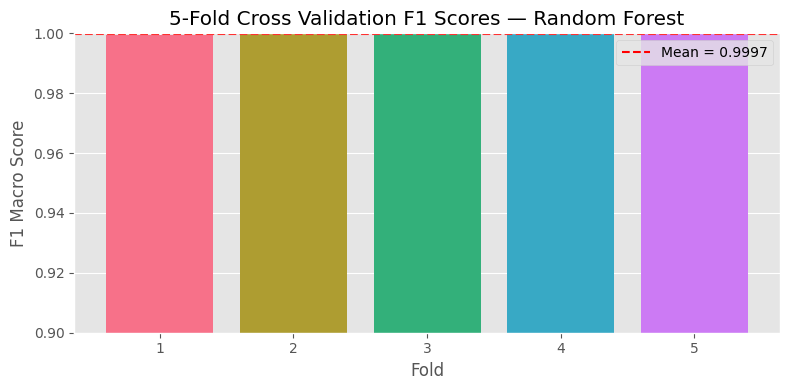

In [ ]:
# ── 5-Fold Cross Validation ───────────────────────────────────────────────────
skf       = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(
    sentinel_brain, X_signal, y_master,
    cv=skf, scoring='f1_macro', n_jobs=-1
)

print(f'Cross Validation F1 Scores : {cv_scores.round(4)}')
print(f'Mean CV F1                 : {cv_scores.mean():.4f}')
print(f'Std  CV F1                 : {cv_scores.std():.4f}')

plt.figure(figsize=(8, 4))
plt.bar(range(1, 6), cv_scores, color=sns.color_palette('husl', 5))
plt.axhline(cv_scores.mean(), color='red', linestyle='--',
            label=f'Mean = {cv_scores.mean():.4f}')
plt.title('5-Fold Cross Validation F1 Scores — Random Forest')
plt.xlabel('Fold')
plt.ylabel('F1 Macro Score')
plt.ylim(0.9, 1.0)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ── Full metrics table ────────────────────────────────────────────────────────
print('\n=== Final Model Performance Summary ===')
print(results_df.sort_values('F1 Macro', ascending=False).to_string(index=False))

print('\n=== Best Model: Random Forest ===')
print(f'  Validation Accuracy : {accuracy_score(y_val, y_pred_best):.4f}')
print(f'  Mean CV F1          : {cv_scores.mean():.4f}')
print(f'  Std  CV F1          : {cv_scores.std():.4f}')


=== Final Model Performance Summary ===
            Model  Accuracy  Precision   Recall  F1 Macro
    Random Forest  0.999718   0.999718 0.999718  0.999718
          XGBoost  0.999555   0.999554 0.999555  0.999554
    Decision Tree  0.998218   0.998221 0.998218  0.998217
Gradient Boosting  0.991165   0.991168 0.991164  0.991162

=== Best Model: Random Forest ===
  Validation Accuracy : 0.9997
  Mean CV F1          : 0.9997
  Std  CV F1          : 0.0000


---
# 📅 Week 7 — Alert Generation & Logging

In [ ]:
# ── Load model and run real-time simulation ───────────────────────────────────
sentinel_brain = joblib.load(os.path.join(MODELS_DIR, 'sentinel_brain.joblib'))
le_alert       = joblib.load(os.path.join(MODELS_DIR, 'label_encoder.joblib'))

X_test_alert = df_test.drop(columns=['attack_class']).values
y_true_alert = le_alert.transform(df_test['attack_class'])

print(f'Simulating real-time detection on {len(X_test_alert)} connections...')
print('True class distribution:')
print(df_test['attack_class'].value_counts())

Simulating real-time detection on 22544 connections...
True class distribution:
attack_class
normal    9711
DoS       7458
R2L       2885
Probe     2421
U2R         67
other        2
Name: count, dtype: int64


In [ ]:
# ── Batch prediction loop ─────────────────────────────────────────────────────
BATCH_SIZE    = 100
all_alerts    = []
total_batches = len(X_test_alert) // BATCH_SIZE

print(f'Processing {len(X_test_alert)} connections in batches of {BATCH_SIZE}...')
print(f'Total batches: {total_batches}')
print('-' * 55)

for batch_num in range(total_batches):
    start       = batch_num * BATCH_SIZE
    end         = start + BATCH_SIZE
    X_batch     = X_test_alert[start:end]
    true_batch  = y_true_alert[start:end]

    preds       = sentinel_brain.predict(X_batch)
    proba       = sentinel_brain.predict_proba(X_batch)
    confidence  = proba.max(axis=1)

    pred_names  = le_alert.inverse_transform(preds)
    true_names  = le_alert.inverse_transform(true_batch)
    timestamp   = datetime.now().strftime('%Y-%m-%d %H:%M:%S')

    for i in range(BATCH_SIZE):
        pred_class = pred_names[i]
        severity   = SEVERITY_MAP.get(pred_class, 'Unknown')
        all_alerts.append({
            'timestamp'       : timestamp,
            'connection_id'   : start + i + 1,
            'predicted_class' : pred_class,
            'true_class'      : true_names[i],
            'confidence'      : round(float(confidence[i]), 4),
            'severity'        : severity,
            'is_intrusion'    : pred_class != 'normal',
            'correct'         : pred_class == true_names[i]
        })

    if (batch_num + 1) % 20 == 0:
        batch_alerts = sum(1 for r in all_alerts[-BATCH_SIZE:] if r['is_intrusion'])
        print(f'Batch {batch_num+1:>4}/{total_batches} | Intrusions in batch: {batch_alerts}')

print('-' * 55)
print(f'Total connections processed: {len(all_alerts)}')

Processing 22544 connections in batches of 100...
Total batches: 225
-------------------------------------------------------
Batch   20/225 | Intrusions in batch: 47
Batch   40/225 | Intrusions in batch: 29
Batch   60/225 | Intrusions in batch: 41
Batch   80/225 | Intrusions in batch: 40
Batch  100/225 | Intrusions in batch: 36
Batch  120/225 | Intrusions in batch: 31
Batch  140/225 | Intrusions in batch: 39
Batch  160/225 | Intrusions in batch: 33
Batch  180/225 | Intrusions in batch: 44
Batch  200/225 | Intrusions in batch: 31
Batch  220/225 | Intrusions in batch: 40
-------------------------------------------------------
Total connections processed: 22500


In [ ]:
# ── Build alerts DataFrame ────────────────────────────────────────────────────
alerts_df    = pd.DataFrame(all_alerts)
total        = len(alerts_df)
intrusions   = alerts_df['is_intrusion'].sum()
normal_count = total - intrusions
accuracy_rt  = alerts_df['correct'].mean()

print(f'Total connections  : {total}')
print(f'Intrusions detected: {intrusions} ({intrusions/total*100:.1f}%)')
print(f'Normal traffic     : {normal_count} ({normal_count/total*100:.1f}%)')
print(f'Real-time Accuracy : {accuracy_rt:.4f}')
print('\nPredicted class distribution:')
print(alerts_df['predicted_class'].value_counts())
print('\nSeverity breakdown:')
print(alerts_df['severity'].value_counts())

Total connections  : 22500
Intrusions detected: 8254 (36.7%)
Normal traffic     : 14246 (63.3%)
Real-time Accuracy : 0.7583

Predicted class distribution:
predicted_class
normal    14246
DoS        6161
Probe      2048
R2L          25
U2R          20
Name: count, dtype: int64

Severity breakdown:
severity
None        14246
Critical     6181
Medium       2048
High           25
Name: count, dtype: int64


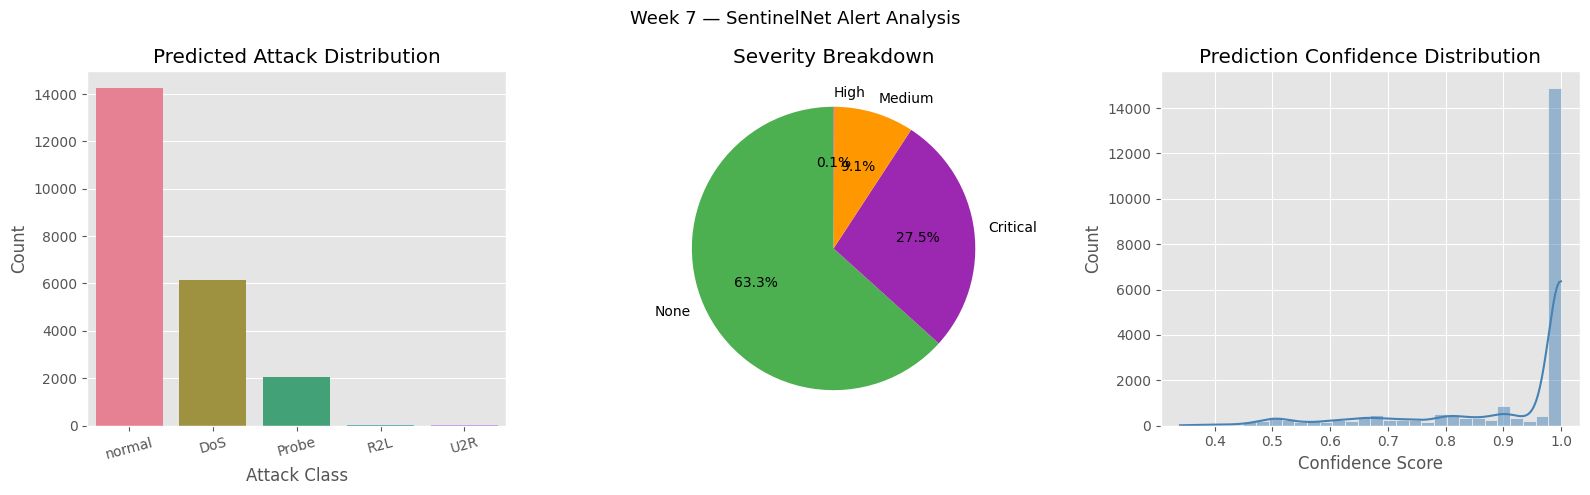

In [ ]:
# ── Alert visualizations ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Predicted class bar chart
class_counts = alerts_df['predicted_class'].value_counts()
sns.barplot(x=class_counts.index, y=class_counts.values, palette='husl', ax=axes[0])
axes[0].set_title('Predicted Attack Distribution')
axes[0].set_xlabel('Attack Class')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=15)

# Severity pie chart
sev_counts  = alerts_df['severity'].value_counts()
colors_sev  = [SEVERITY_COLOR.get(s, '#999') for s in sev_counts.index]
axes[1].pie(sev_counts.values, labels=sev_counts.index,
            colors=colors_sev, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Severity Breakdown')

# Confidence distribution
sns.histplot(alerts_df['confidence'], bins=30, kde=True, color='steelblue', ax=axes[2])
axes[2].set_title('Prediction Confidence Distribution')
axes[2].set_xlabel('Confidence Score')

plt.suptitle('Week 7 — SentinelNet Alert Analysis', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# ── Save alert logs ───────────────────────────────────────────────────────────
# Full CSV
csv_path = os.path.join(ALERTS_DIR, 'alerts.csv')
alerts_df.to_csv(csv_path, index=False)
print(f'Saved full alert log → {csv_path}')

# Intrusions-only CSV
intru_path = os.path.join(ALERTS_DIR, 'intrusions_only.csv')
alerts_df[alerts_df['is_intrusion']].to_csv(intru_path, index=False)
print(f'Saved intrusions log → {intru_path}')

# Human-readable text log
log_path = os.path.join(ALERTS_DIR, 'alert_log.txt')
with open(log_path, 'w') as f:
    f.write('=' * 60 + '\n')
    f.write('       SENTINELNET — INTRUSION ALERT LOG\n')
    f.write(f'       Generated: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}\n')
    f.write('=' * 60 + '\n\n')
    f.write('SUMMARY\n')
    f.write(f'  Total connections  : {total}\n')
    f.write(f'  Intrusions detected: {intrusions} ({intrusions/total*100:.1f}%)\n')
    f.write(f'  Normal traffic     : {normal_count} ({normal_count/total*100:.1f}%)\n')
    f.write(f'  Real-time Accuracy : {accuracy_rt:.4f}\n\n')
    f.write('SEVERITY BREAKDOWN\n')
    for sev, cnt in alerts_df['severity'].value_counts().items():
        f.write(f'  {sev:<12}: {cnt}\n')
    f.write('\nATTACK CLASS BREAKDOWN\n')
    for cls, cnt in alerts_df['predicted_class'].value_counts().items():
        f.write(f'  {cls:<12}: {cnt}\n')
    f.write('\n' + '=' * 60 + '\n')
    f.write('CRITICAL & HIGH SEVERITY ALERTS (first 50)\n')
    f.write('=' * 60 + '\n\n')
    critical = alerts_df[alerts_df['severity'].isin(['Critical', 'High'])]
    for _, row in critical.head(50).iterrows():
        f.write(
            f'[{row["timestamp"]}] '
            f'ID:{row["connection_id"]:>6} | '
            f'SEVERITY: {row["severity"]:<10} | '
            f'CLASS: {row["predicted_class"]:<8} | '
            f'CONFIDENCE: {row["confidence"]:.2f}\n'
        )
print(f'Saved text alert log → {log_path}')

# JSON dashboard data
dashboard = {
    'summary'    : {
        'total'       : int(total),
        'intrusions'  : int(intrusions),
        'normal'      : int(normal_count),
        'accuracy'    : round(float(accuracy_rt), 4),
        'generated_at': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    },
    'by_class'   : alerts_df['predicted_class'].value_counts().to_dict(),
    'by_severity': alerts_df['severity'].value_counts().to_dict(),
    'alerts'     : alerts_df[alerts_df['is_intrusion']].head(200).to_dict(orient='records')
}
json_path = os.path.join(ALERTS_DIR, 'dashboard_data.json')
with open(json_path, 'w') as f:
    json.dump(dashboard, f, indent=2)
print(f'Saved dashboard JSON → {json_path}')

print('\nFiles in alerts/:')
for fname in os.listdir(ALERTS_DIR):
    size = os.path.getsize(os.path.join(ALERTS_DIR, fname))
    print(f'  {fname:<35} ({size:,} bytes)')

Saved full alert log → alerts/alerts.csv
Saved intrusions log → alerts/intrusions_only.csv
Saved text alert log → alerts/alert_log.txt
Saved dashboard JSON → alerts/dashboard_data.json

Files in alerts/:
  alert_log.txt                       (5,340 bytes)
  dashboard_data.json                 (49,933 bytes)
  intrusions_only.csv                 (474,629 bytes)
  alerts.csv                          (1,319,938 bytes)


---
# 📅 Week 8 — Documentation & Project Summary

In [ ]:
# ── Final performance dashboard ───────────────────────────────────────────────
print('=' * 60)
print('       SENTINELNET — PROJECT SUMMARY')
print('=' * 60)
print(f"\nDataset       : NSL-KDD")
print(f"Train samples : {len(X_signal):,} (after SMOTE balancing)")
print(f"Test  samples : {len(X_test_alert):,}")
print(f"Features used : {X_signal.shape[1]}")
print(f"\nAttack classes: {list(le_w4.classes_)}")
print(f"\n--- Best Model: Random Forest ---")
print(f"  Best Hyperparameters  : {grid.best_params_}")
print(f"  Validation F1 (macro) : {f1_score(y_val, y_pred_best, average='macro'):.4f}")
print(f"  Validation Accuracy   : {accuracy_score(y_val, y_pred_best):.4f}")
print(f"  5-Fold CV F1 Mean     : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"\n--- Alert Generation ---")
print(f"  Connections processed : {total:,}")
print(f"  Intrusions detected   : {intrusions:,} ({intrusions/total*100:.1f}%)")
print(f"  Real-time Accuracy    : {accuracy_rt:.4f}")
print(f"\n--- Anomaly Detection ---")
print(f"  Isolation Forest anomalies : {iso_anomaly_count:,}")
print(f"  LOF anomalies (5k sample)  : {lof_count}")
print(f"  OC-SVM anomalies (5k)      : {ocsvm_count}")
print('=' * 60)

       SENTINELNET — PROJECT SUMMARY

Dataset       : NSL-KDD
Train samples : 336,715 (after SMOTE balancing)
Test  samples : 22,544
Features used : 37

Attack classes: ['DoS', 'Probe', 'R2L', 'U2R', 'normal', 'other']

--- Best Model: Random Forest ---
  Best Hyperparameters  : {'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 100}
  Validation F1 (macro) : 0.9997
  Validation Accuracy   : 0.9997
  5-Fold CV F1 Mean     : 0.9997 ± 0.0000

--- Alert Generation ---
  Connections processed : 22,500
  Intrusions detected   : 8,254 (36.7%)
  Real-time Accuracy    : 0.7583

--- Anomaly Detection ---
  Isolation Forest anomalies : 10,092
  LOF anomalies (5k sample)  : 250
  OC-SVM anomalies (5k)      : 439


In [ ]:
import joblib, os
from google.colab import files

# Save everything needed for inference
joblib.dump(sentinel_brain,  'models/sentinel_brain.joblib')   # already done
joblib.dump(le_w4,           'models/label_encoder.joblib')    # already done
joblib.dump(ohe,             'models/ohe_encoder.joblib')      # NEW — needed for preprocessing
joblib.dump(freq_map,        'models/freq_map.joblib')         # NEW — needed for preprocessing
joblib.dump(scaler,          'models/scaler.joblib')           # NEW — needed for preprocessing
joblib.dump(selected_features, 'models/selected_features.joblib')  # NEW — feature list

# Download all of them
for f in ['sentinel_brain.joblib','label_encoder.joblib',
          'ohe_encoder.joblib','freq_map.joblib',
          'scaler.joblib','selected_features.joblib']:
    files.download(f'models/{f}')
    print(f'⬇ Downloading {f}...')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇ Downloading sentinel_brain.joblib...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

⬇ Downloading scaler.joblib...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇ Downloading selected_features.joblib...


In [ ]:
import os, time

os.system("pkill -f ngrok 2>/dev/null")
os.system("pkill -f cloudflared 2>/dev/null")
os.system("pkill -f flask 2>/dev/null")
os.system("fuser -k 5001/tcp 2>/dev/null")
time.sleep(2)
print("✅ Cleaned up")

In [ ]:
import threading, time, subprocess, re, os, requests
from flask import Flask, request, jsonify
from flask_cors import CORS
import pandas as pd, numpy as np

flask_app = Flask(__name__)

# ← This is the key fix: explicit CORS for all origins + all headers
CORS(flask_app, origins="*",
     allow_headers=["Content-Type", "cf-access-client-id", "ngrok-skip-browser-warning"],
     methods=["GET", "POST", "OPTIONS"])

@flask_app.after_request
def after_request(response):
    response.headers.add('Access-Control-Allow-Origin', '*')
    response.headers.add('Access-Control-Allow-Headers', 'Content-Type,cf-access-client-id')
    response.headers.add('Access-Control-Allow-Methods', 'GET,POST,OPTIONS')
    return response

@flask_app.route('/health')
def health():
    return jsonify({'status': 'online', 'model': 'sentinel_brain'})

@flask_app.route('/predict', methods=['POST', 'OPTIONS'])
def predict():
    if request.method == 'OPTIONS':
        return jsonify({}), 200
    try:
        data = request.get_json(force=True)
        rows = data.get('rows', [])
        df = pd.DataFrame(rows)
        for col in COLUMNS:
            if col not in df.columns:
                df[col] = 0
        if 'label' not in df.columns:
            df['label'] = 'normal'
        df_proc, _, _, _ = preprocess(df, is_train=False,
                                       ohe=ohe, freq_map=freq_map, scaler=scaler)
        model_feats = (list(sentinel_brain.feature_names_in_)
                       if hasattr(sentinel_brain, 'feature_names_in_')
                       else selected_features)
        for f in model_feats:
            if f not in df_proc.columns:
                df_proc[f] = 0
        X = df_proc[model_feats].values
        preds = sentinel_brain.predict(X)
        proba = sentinel_brain.predict_proba(X)
        classes = le_w4.inverse_transform(preds)
        out = [{'predicted_class': cls, 'severity': SEVERITY_MAP.get(cls,'Unknown'),
                'confidence': round(float(conf), 4), 'is_intrusion': cls != 'normal'}
               for cls, conf in zip(classes, proba.max(axis=1))]
        return jsonify({'status': 'ok', 'results': out})
    except Exception as e:
        import traceback
        return jsonify({'status': 'error', 'message': str(e),
                        'trace': traceback.format_exc()}), 500

def run_flask():
    import logging
    logging.getLogger('werkzeug').setLevel(logging.ERROR)
    flask_app.run(host='0.0.0.0', port=5001, debug=False, use_reloader=False)

os.system("fuser -k 5001/tcp 2>/dev/null")
time.sleep(1)
threading.Thread(target=run_flask, daemon=True).start()
time.sleep(2)
print("✅ Flask running — CORS fixed")

In [ ]:
import threading, time, subprocess, re, os, requests
from flask import Flask, request, jsonify
from flask_cors import CORS
import pandas as pd
import numpy as np

# ── Flask app ────────────────────────────────────────────────────────────────
flask_app = Flask(__name__)
CORS(flask_app, origins="*")

@flask_app.route('/health')
def health():
    return jsonify({'status': 'online', 'model': 'sentinel_brain'})

@flask_app.route('/predict', methods=['POST'])
def predict():
    try:
        data = request.get_json(force=True)
        rows = data.get('rows', [])
        df = pd.DataFrame(rows)
        for col in COLUMNS:
            if col not in df.columns:
                df[col] = 0
        if 'label' not in df.columns:
            df['label'] = 'normal'
        df_proc, _, _, _ = preprocess(df, is_train=False,
                                       ohe=ohe, freq_map=freq_map, scaler=scaler)
        model_feats = (list(sentinel_brain.feature_names_in_)
                       if hasattr(sentinel_brain, 'feature_names_in_')
                       else selected_features)
        for f in model_feats:
            if f not in df_proc.columns:
                df_proc[f] = 0
        X = df_proc[model_feats].values
        preds = sentinel_brain.predict(X)
        proba = sentinel_brain.predict_proba(X)
        classes = le_w4.inverse_transform(preds)
        out = [
            {
                'predicted_class': cls,
                'severity': SEVERITY_MAP.get(cls, 'Unknown'),
                'confidence': round(float(conf), 4),
                'is_intrusion': cls != 'normal'
            }
            for cls, conf in zip(classes, proba.max(axis=1))
        ]
        return jsonify({'status': 'ok', 'results': out})
    except Exception as e:
        import traceback
        return jsonify({'status': 'error', 'message': str(e),
                        'trace': traceback.format_exc()}), 500

# ── Start Flask in background ────────────────────────────────────────────────
def run_flask():
    import logging
    log = logging.getLogger('werkzeug')
    log.setLevel(logging.ERROR)  # suppress request logs
    flask_app.run(host='0.0.0.0', port=5001, debug=False, use_reloader=False)

threading.Thread(target=run_flask, daemon=True).start()
time.sleep(2)

# Quick health check
try:
    r = requests.get("http://localhost:5001/health", timeout=3)
    print("✅ Flask is up:", r.json())
except Exception as e:
    print("❌ Flask not responding:", e)
    raise

# ── Install cloudflared ───────────────────────────────────────────────────────
print("Installing cloudflared...")
os.system("wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O /usr/local/bin/cloudflared")
os.system("chmod +x /usr/local/bin/cloudflared")
v = os.popen("cloudflared version").read().strip()
print("✅ cloudflared:", v)

# ── Start tunnel ─────────────────────────────────────────────────────────────
lines = []

def read_output(proc):
    for line in proc.stdout:
        decoded = line.decode("utf-8", errors="ignore").strip()
        if decoded:
            lines.append(decoded)

cf_proc = subprocess.Popen(
    ["cloudflared", "tunnel", "--url", "http://localhost:5001"],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT
)
threading.Thread(target=read_output, args=(cf_proc,), daemon=True).start()

# Wait and scan for URL
print("Waiting for tunnel URL", end="")
public_url = None
for _ in range(30):
    time.sleep(1)
    print(".", end="", flush=True)
    all_text = "\n".join(lines)
    match = re.search(r'https://[a-z0-9\-]+\.trycloudflare\.com', all_text)
    if match:
        public_url = match.group(0)
        break

print()  # newline after dots

if public_url:
    print("=" * 55)
    print(f"  ✅ PUBLIC URL : {public_url}")
    print(f"  Health       : {public_url}/health")
    print(f"  Predict      : {public_url}/predict")
    print("=" * 55)
    print("\n👆 Copy the PUBLIC URL above → paste into SentinelNet frontend")
else:
    print("❌ Could not find tunnel URL. Output so far:")
    print("\n".join(lines[-20:]))


In [ ]:
# Download real NSL-KDD test set directly
import requests as req

url = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTest+.txt"
r = req.get(url)
with open("/content/KDDTest+.txt", "wb") as f:
    f.write(r.content)

print("✅ Downloaded KDDTest+.txt")
print("Rows:", len(r.text.strip().split('\n')))
print("\nNow download this file from Colab:")
print("  Files panel (left sidebar) → right-click KDDTest+.txt → Download")
print("Then drag it into the SentinelNet upload zone")